<a href="https://colab.research.google.com/github/Parv-01/Kshitij_Sir_Repo_Check_IITP/blob/main/e_THERAPIST_executability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# e-THERAPIST: Executability Study

This notebook checks the released repository through a small, reproducible training and inference experiment. It includes environment verification, dataset analysis, model loading, at most five optimizer updates, checkpoint persistence and held-out evaluation.

**Source:** [Mishrakshitij/e-THERAPIST](https://github.com/Mishrakshitij/e-THERAPIST)  
**Protocol:** fixed small subsets, tiny Hugging Face checkpoints, and four to eight held-out predictions.  
**Interpretation:** a passing result verifies the tested code path at smoke-test scale. It does not measure research performance.

## Running or reviewing this notebook

The saved outputs can be viewed directly in Google Colab. To repeat the experiment, run the cells in order with internet access. A GPU is optional for these tiny models. Python 3.11 is the tested interpreter. The setup cell installs dependencies and checks out the exact source revision when a prepared checkout is not supplied.


## Environment and source verification

In [ ]:
from pathlib import Path
import os, sys, subprocess, importlib.metadata as metadata
PROJECT = 'e-THERAPIST'
COMMIT = 'f9740e09a6eb7f617945b31aa029cec395351f7e'
REPO_URL = 'https://github.com/Mishrakshitij/' + PROJECT + '.git'
prepared = os.environ.get('EXEC_CHECK_PREPARED') == '1'
if not prepared:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *['torch>=2.6,<3', 'transformers==4.57.6', 'peft==0.18.1', 'accelerate>=1.2,<2', 'pandas>=2.2,<4', 'matplotlib>=3.8,<4', 'nltk>=3.9,<4', 'sentencepiece>=0.2,<1', 'sacrebleu>=2.4,<3', 'rouge-score>=0.1.2,<0.2', 'ipython', 'numpy>=1.26,<3']], check=True)
REPO_ROOT = Path(os.environ.get('EXEC_CHECK_REPO', str(Path.cwd() / (PROJECT + '_source')))).resolve()
if not (REPO_ROOT / '.git').exists():
    subprocess.run(['git', 'clone', '-q', REPO_URL, str(REPO_ROOT)], check=True)
    subprocess.run(['git', '-C', str(REPO_ROOT), 'checkout', '-q', COMMIT], check=True)
actual_commit = subprocess.check_output(['git','-C',str(REPO_ROOT),'rev-parse','HEAD'], text=True).strip()
assert actual_commit == COMMIT, 'The source revision must match the verified experiment.'
OUTPUT_DIR = Path(os.environ.get('EXEC_CHECK_OUTPUT', str(Path.cwd() / (PROJECT + '_outputs')))).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['WANDB_DISABLED'] = 'true'
os.environ['USE_TF'] = '0'
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_num_threads(2)
torch.manual_seed(42)
%matplotlib inline
CAUSAL_MODEL = 'sshleifer/tiny-gpt2'
SEQ2SEQ_MODEL = 'hf-internal-testing/tiny-random-bart'
ENCODER_MODEL = 'hf-internal-testing/tiny-random-roberta'
DISTILBERT_MODEL = 'hf-internal-testing/tiny-random-DistilBertModel'
print('Source revision verified:', actual_commit)
print('Python:', sys.version.split()[0], '| Device:', DEVICE)
print({package: metadata.version(package) for package in ['torch','transformers','numpy','pandas','matplotlib']})


Source revision verified: f9740e09a6eb7f617945b31aa029cec395351f7e
Python: 3.11.16 | Device: cuda
{'torch': '2.13.0+cu129', 'transformers': '4.57.6', 'numpy': '2.3.5', 'pandas': '3.0.5', 'matplotlib': '3.10.7'}


### Compatibility with the repository requirements
The table checks installed versions against the base dependencies and optional dependency groups used by this experiment.

In [ ]:
import tomllib
from packaging.requirements import Requirement
from packaging.version import Version
import pandas as pd
from IPython.display import display
project_metadata = tomllib.loads((REPO_ROOT / 'pyproject.toml').read_text())['project']
assert Version(sys.version.split()[0]) in __import__('packaging.specifiers', fromlist=['SpecifierSet']).SpecifierSet(project_metadata['requires-python'])
extras = {
    'PACD': ['baselines', 'plots'], 'PADS': ['train', 'politeness', 'plots'],
    'RL-Emo-Per': ['train', 'figures'], 'PEPDS': ['train', 'plots'],
    'GenPADS': ['train', 'metrics', 'figures'], 'Po-Em-MHLCDS': ['plots'],
    'PAL': ['train', 'eval', 'plots'], 'e-THERAPIST': [],
    'Re-Po-PDS': ['train', 'plots'], 'ABLE': ['train', 'plots'], 'EDiSS': ['train', 'plots']
}[PROJECT]
specs = list(project_metadata.get('dependencies', []))
for extra in extras:
    specs += project_metadata.get('optional-dependencies', {}).get(extra, [])
dependency_rows = []
for spec in specs:
    requirement = Requirement(spec)
    if requirement.marker and not requirement.marker.evaluate():
        continue
    installed = metadata.version(requirement.name)
    compatible = Version(installed) in requirement.specifier
    dependency_rows.append({'requirement': spec, 'installed': installed, 'compatible': compatible})
assert dependency_rows and all(row['compatible'] for row in dependency_rows)
display(pd.DataFrame(dependency_rows))
(OUTPUT_DIR / 'environment_check.json').write_text(__import__('json').dumps({'python': sys.version.split()[0], 'checked_extras': extras, 'dependencies': dependency_rows}, indent=2))
print('PASS: Python and all dependencies declared for the tested paths are compatible.')


,requirement,installed,compatible
0,"numpy>=1.24,<3",2.3.5,True
1,"torch>=2.2,<3",2.13.0+cu129,True
2,"transformers>=4.46,<6",4.57.6,True
3,"PyYAML>=6,<7",6.0.3,True
4,safetensors>=0.4,0.8.0,True


PASS: Python and all dependencies declared for the tested paths are compatible.


# e-THERAPIST: repository executability study
This notebook checks the native supervised generator using the released
PSYCON data and downloaded `sshleifer/tiny-gpt2` weights. Five optimizer updates
are followed by native checkpoint reload and evaluation on four held-out
examples. Six reward classifiers, the NLPO stage, and the paper's full
GPT-2-medium configuration are outside this deliberately small execution check.

In [ ]:
import importlib.metadata as metadata
import json
import math
from pathlib import Path
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import torch
from torch.optim.optimizer import register_optimizer_step_post_hook
from transformers import AutoModelForCausalLM

sys.path.insert(0, str(REPO_ROOT / "src"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
from e_therapist.data import load_turns, validate_splits, dataset_stats
from e_therapist.training import generation_examples, train_sft
from e_therapist.evaluation import evaluate_generator
from e_therapist.tokenization import load_tokenizer

COMMIT = subprocess.check_output(["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"], text=True).strip()
VERSIONS = {name: metadata.version(name) for name in ("torch", "transformers", "numpy", "PyYAML", "pandas", "matplotlib")}
print("Repository: Mishrakshitij/e-THERAPIST | revision:", COMMIT)
print("Backbone:", CAUSAL_MODEL, "| device:", DEVICE)
display(pd.Series(VERSIONS, name="Installed version").to_frame())

python_environment/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository: Mishrakshitij/e-THERAPIST | revision: f9740e09a6eb7f617945b31aa029cec395351f7e
Backbone: sshleifer/tiny-gpt2 | device: cuda


,Installed version
torch,2.13.0+cu129
transformers,4.57.6
numpy,2.3.5
PyYAML,6.0.3
pandas,3.0.5
matplotlib,3.10.7


## Dataset validation and exploratory analysis
The shipped dataset contains 1,020 conversations and 19,676 turns. Native
loaders validate labels and identifiers, while the split validator checks
conversation separation. Training examples come from the native loader.

,conversations,turns,nonempty_turns,generation_examples
train,816,15509,15507,7515
validation,102,2093,2093,1014
test,102,2074,2074,1000


Native data/split validation: PASS | turns: 19676 | eligible response examples: 9529


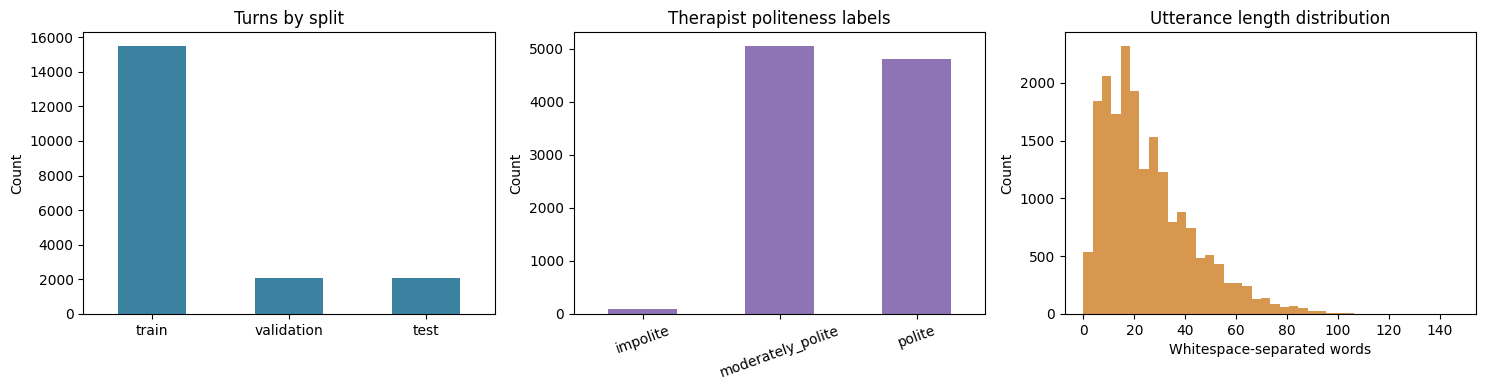

In [ ]:
DATA = REPO_ROOT / "data" / "psycon" / "psycon.csv"
SPLITS = REPO_ROOT / "data" / "psycon" / "splits.json"
turns = load_turns(DATA)
split_manifest = json.loads(SPLITS.read_text())
validate_splits(turns, split_manifest)
integrity = dataset_stats(turns, split_manifest)
split_table = pd.DataFrame(integrity["splits"]).T
display(split_table)
print("Native data/split validation: PASS | turns:", integrity["turns"],
      "| eligible response examples:", integrity["generation_examples"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
split_table["turns"].plot.bar(ax=axes[0], color="#3b82a0", rot=0, title="Turns by split")
pd.Series(integrity["turn_labels"]["politeness"]).plot.bar(ax=axes[1], color="#8e74b5", rot=20,
    title="Therapist politeness labels")
word_lengths = [len(row["utterance"].split()) for row in turns]
axes[2].hist(word_lengths, bins=40, color="#d7974f")
axes[2].set_title("Utterance length distribution")
axes[2].set_xlabel("Whitespace-separated words")
for axis in axes:
    axis.set_ylabel("Count")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset-overview.png", dpi=160, bbox_inches="tight")
plt.show()

## Small released-data selection
The native trainer has an epoch budget rather than a `max_steps` option.
Selecting five training examples, a batch size of one, no accumulation, and
one epoch gives five optimizer updates. A runtime hook verifies the actual
count. The validation subset contains five examples; final evaluation uses
four examples from the separate released test split.

In [ ]:
CHECKPOINT = OUTPUT_DIR / "sft" / "best"
config = {"data": str(DATA), "splits": str(SPLITS), "model": CAUSAL_MODEL,
          "output": str(OUTPUT_DIR / "sft"), "device": DEVICE, "seed": 42,
          "epochs": 1, "batch_size": 1, "gradient_accumulation": 1,
          "max_examples": 5, "context_window": 2, "max_length": 96,
          "max_response_length": 8, "learning_rate": 5e-4, "top_k": 1}
train_examples = generation_examples(config, "train")
validation_examples = generation_examples(config, "validation")
test_config = config | {"max_examples": 4}
test_examples = generation_examples(test_config, "test")
assert len(train_examples) == len(validation_examples) == 5 and len(test_examples) == 4
assert {x["conversation_id"] for x in train_examples}.isdisjoint(x["conversation_id"] for x in test_examples)
display(pd.DataFrame([{"split": split, "selected responses": len(rows)} for split, rows in
    (("train", train_examples), ("validation", validation_examples), ("test", test_examples))]))
display(pd.DataFrame([{"conversation_id": x["conversation_id"], "prompt excerpt": x["prompt"][:240],
                       "reference excerpt": x["response"][:240]} for x in train_examples[:3]]))

,split,selected responses
0,train,5
1,validation,5
2,test,4


,conversation_id,prompt excerpt,reference excerpt
0,combined-001,"Patient (sentiment=negative): Hi, therapist. I...",It sounds like your boyfriend is comfortable i...
1,combined-001,Therapist: It sounds like your boyfriend is co...,If you feel like you're putting in all the eff...
2,combined-001,Therapist: If you feel like you're putting in ...,While it's important to be supportive of your ...


## Native supervised training and checkpoint saving
The repository loads the downloaded backbone, applies its response-only
cross-entropy objective, runs the optimizer, computes validation perplexity,
and saves its best validation checkpoint. A single epoch is sufficient for
this serialization and execution check.

In [ ]:
observed_steps = []
step_hook = register_optimizer_step_post_hook(lambda *args, **kwargs: observed_steps.append(len(observed_steps) + 1))
started = time.perf_counter()
try:
    training = train_sft(config)
finally:
    step_hook.remove()
training_seconds = time.perf_counter() - started
assert len(observed_steps) == 5
assert all(math.isfinite(training[key]) for key in ("train_nll", "validation_nll", "validation_perplexity"))
assert (CHECKPOINT / "config.json").is_file()
assert (CHECKPOINT / "model.safetensors").is_file()
display(pd.DataFrame([training]))
print("Observed optimizer updates:", len(observed_steps))

{"epoch": 1, "train_nll": 10.823480415344239, "validation_nll": 10.821391677856445, "validation_perplexity": 50080.734783280226}


python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
python_environment/bin/x86_64-conda-linux-gnu-ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


,epoch,train_nll,validation_nll,validation_perplexity
0,1,10.82348,10.821392,50080.734783


Observed optimizer updates: 5


## Saved model reload and native evaluation
The saved tokenizer and model are reopened before the repository evaluator
independently reloads the same checkpoint. It generates four responses and
computes held-out reference-token perplexity and text statistics. Optional
attribute-classifier and BERTScore metrics are intentionally outside the scope.

In [ ]:
tokenizer = load_tokenizer(CHECKPOINT)
model = AutoModelForCausalLM.from_pretrained(CHECKPOINT).to(DEVICE).eval()
parameter_count = sum(p.numel() for p in model.parameters())
assert tokenizer.eos_token_id is not None
print("Checkpoint save/reload: PASS | parameters:", parameter_count)
display(pd.DataFrame([{"file": p.name, "bytes": p.stat().st_size} for p in sorted(CHECKPOINT.iterdir()) if p.is_file()]))
del model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
evaluation_config = test_config | {"model": str(CHECKPOINT), "output": str(OUTPUT_DIR / "evaluation")}
evaluation = evaluate_generator(evaluation_config, split="test", with_bertscore=False, with_attributes=False)
records = [json.loads(line) for line in (OUTPUT_DIR / "evaluation" / "test-predictions.jsonl").read_text().splitlines()]
assert len(records) == 4 and all(isinstance(row["response"], str) for row in records)
assert math.isfinite(evaluation["reference_response_perplexity"])
display(pd.DataFrame([{**row, "reference": row["reference"][:240]} for row in records]))
display(pd.DataFrame([evaluation]))

Checkpoint save/reload: PASS | parameters: 102714


,file,bytes
0,config.json,895
1,generation_config.json,119
2,merges.txt,456318
3,model.safetensors,413296
4,special_tokens_map.json,470
5,tokenizer.json,3557680
6,tokenizer_config.json,556
7,vocab.json,798156


,conversation_id,turn_id,response,reference
0,combined-014,2,stairs stairs stairs stairs stairs stairs stai...,It's important to remember that your son is hi...
1,combined-014,4,stairs stairs stairs stairs stairs stairs stai...,That's understandable. It's important to suppo...
2,combined-014,6,stairs stairs stairs stairs stairs stairs stai...,It's important to remember that their opinions...
3,combined-014,8,stairs stairs stairs stairs stairs stairs stai...,"It's natural to have concerns, but remember th..."


,count,response_length_words,distinct_1,distinct_2,reference_response_perplexity,reference_response_tokens
0,4,8.0,0.03125,0.035714,50069.447811,32


In [ ]:
result = {
    "project": "e-THERAPIST", "status": "PASS", "scope": "native supervised generator smoke check",
    "commit": COMMIT, "model": CAUSAL_MODEL, "versions": VERSIONS, "updates": len(observed_steps),
    "counts": {"dataset_rows": integrity["turns"], "conversations": integrity["conversations"],
               "train": 5, "validation": 5, "evaluation": 4},
    "dataset_integrity": True, "checkpoint_saved": True, "checkpoint_reloaded": True,
    "checkpoints": ["sft/best"], "parameter_count": parameter_count,
    "training_seconds": training_seconds, "metrics": {"training": training, "evaluation": evaluation},
    "limitations": ["The downloaded tiny GPT-2 replaces the paper's GPT-2-medium model.",
                    "Reward classifiers, NLPO, and BERTScore are outside this check.",
                    "Five updates and four predictions verify execution, not model quality."],
}
(OUTPUT_DIR / "result.json").write_text(json.dumps(result, indent=2, allow_nan=False) + "\n")
print("PASS: native dataset validation, five optimizer updates, checkpoint save/reload, and four native predictions.")

PASS: native dataset validation, five optimizer updates, checkpoint save/reload, and four native predictions.


## Project summary

**Result: PASS for the tested configuration.**

The source revision and execution environment were checked, the released data were inspected and visualized, and the selected small model was loaded. Native training completed **5 optimizer updates**. Checkpoint files were saved and reloaded, and the evaluation covered **4 held-out evaluation samples**. The assertions and outputs above verify that this project is executable for the tested configuration.

The conclusion applies to the native paths exercised here with tiny models and bounded subsets.